# Greenhouse Gas Emissions - Plots, Visualizations

In this notebook we will visually explore the GHG emission dataset. We will focus mainly on comparisons between emission of different GHGs and comparisons between countries.

In [ ]:
import os

import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import dash
from dash import Dash, html, dcc, Input, Output

import matplotlib.pyplot as plt
import matplotlib
plt.style.use('ggplot')
# %matplotlib inline  # to ensure plots appear directly in notebook
matplotlib.rcParams['figure.figsize'] = (12, 8)

In [2]:
# import datasets

PROJECT_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(PROJECT_DIR, "data")

df_countries_clean = pd.read_csv(
    os.path.join(DATA_DIR, "ghg_per_year_clean.csv")
    )
df_countries_cumul = pd.read_csv(
    os.path.join(DATA_DIR, "ghg_cumul_clean.csv")
    )

### How much does/did each gas contribute to GHG emission?

In [3]:
# calculate the total emission for each GHG
mask = (df_countries_cumul['entity'] == 'World') \
    & (df_countries_cumul['year'] == 2022)

# transform df to series
series = df_countries_cumul.loc[mask, list(df_countries_cumul)[3:6]].squeeze()
series

n2o_in_co2_equivalents_cumul    1.837983e+11
ch4_in_co2_equivalents_cumul    7.409901e+11
co2_cumul                       2.525335e+12
Name: 33561, dtype: float64

In [4]:
# plot piechart

labels = ["N₂O", "CH₄", "CO₂"]

fig = go.Figure(
    data=[go.Pie(labels=labels, values=series, textinfo='label+percent')]
    )

fig.update_layout(
    title_text="Cumulated Global GHG Emissions Shares by Gas (1850-2022)",
    height=500,  # Total height of the figure
    width=800,   # Total width of the figure
)

fig.show()

Let us now inspect how these shares changed over the years. In order to prepare the input for the plotly piechart, we reshape the dataset using the `df.melt()` pandas method. The CO2, CH4, and N2O columns are merged in one single column, and each year appears 3 times in the the year column. The resulting 'variable' column ensures that the numbers in the column 'values' are correctly attributed to the coressponding GHG.

In [5]:
# rename columns
col_list_1 = ['n2o_in_co2_equivalents_cumul',
              'ch4_in_co2_equivalents_cumul',
              'co2_cumul']
col_rename_list_1 = ["N₂O", "CH₄", "CO₂"]
col_rename_dict_1 = dict(zip(col_list_1, col_rename_list_1))

df_plot_1 = df_countries_cumul.loc[
    df_countries_cumul['entity'] == 'World',
    list(df_countries_cumul)[2:6]
    ].rename(columns=col_rename_dict_1)

# reshape the dataframe
df_plot_1 = df_plot_1.melt(id_vars='year')
df_plot_1.sort_values("year")

,year,variable,value
173,1850,CH₄,1.239410e+09
346,1850,CO₂,2.839369e+09
0,1850,N₂O,1.380856e+08
347,1851,CO₂,5.769622e+09
1,1851,N₂O,2.787152e+08
...,...,...,...
517,2021,CO₂,2.484939e+12
171,2021,N₂O,1.808284e+11
345,2022,CH₄,7.409901e+11
172,2022,N₂O,1.837983e+11


We now plot the same as above, but with a slider that allows to select the year. The plot shows that, throughout the whole period between 1850 - 2022, CO2 was the most emitted GHG and at any given time had a (cumulative) share of approx. 70%.

In [6]:
# get unique years and variables
years = df_plot_1['year'].unique()
categories = df_plot_1['variable'].unique()

# define the initial pie chart (for the first year)
initial_year = years[0]
initial_data = df_plot_1[df_plot_1['year'] == initial_year]

fig = go.Figure(
    data=[
        go.Pie(
            labels=initial_data['variable'],
            values=initial_data['value'],
            textinfo='label+percent'
            )
        ],
    layout=go.Layout(
        title="Cumulated Global GHG Emissions Shares by Gas Thro",
        updatemenus=[  # define the interactive buttons
            {
                "buttons": [
                    {
                        "args": [
                            None,
                            {
                                "frame": {"duration": 50, "redraw": True},
                                "fromcurrent": True
                                }
                                ],
                        "label": "Play",  # play button
                        "method": "animate"
                    },
                    {
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": True},
                                "mode": "immediate",
                                "transition": {"duration": 0}
                                }],
                        "label": "Pause",  # pause button
                        "method": "animate"
                    }
                ],
                "direction": "left",
                "pad": {"r": 10, "t": 87},
                "showactive": False,
                "type": "buttons",
                "x": 0.1,
                "xanchor": "right",
                "y": 0,
                "yanchor": "top"  # placement of the buttons
            }
        ]
    ),
    frames=[  # define all frame throught a for loop
        go.Frame(
            data=[
                go.Pie(
                    labels=df_plot_1[df_plot_1['year'] == year]['variable'],
                    values=df_plot_1[df_plot_1['year'] == year]['value'],
                    textinfo='label+percent')
                ],
            name=str(year)
        ) for year in years
    ]
)

# set layout for slider & plot dimensions
fig.update_layout(
    height=500,
    width=1000,
    sliders=[
        {
            "steps": [
                {
                    "args": [
                        [str(year)],
                        {
                            "frame": {"duration": 30, "redraw": True},
                            "mode": "immediate",
                            "transition": {"duration": 30}
                            }
                            ],
                    "label": str(year),
                    "method": "animate"
                } for year in years
            ],
            "transition": {"duration": 30},
            "x": 0.1,
            "len": 0.9
        }
    ]
)

fig.show()

## Which countries contributed the most to GHG emissions?

Here are the top ten countries:

In [8]:
col_rename_list = list(df_countries_cumul)[3:]
df_ghg_total = df_countries_cumul.loc[
    df_countries_cumul['year'] == 2022,
    tuple(['entity'] + col_rename_list)
    ].reset_index(drop=True)


df_ghg_total.sort_values(
    'ghg_in_co2_equivalents_cumul',
    ascending=False
    ).head(11)

,entity,n2o_in_co2_equivalents_cumul,ch4_in_co2_equivalents_cumul,co2_cumul,ghg_in_co2_equivalents_cumul
193,World,1.837983e+11,7.409901e+11,2.525335e+12,3.450124e+12
187,United States,2.350769e+10,7.845273e+10,5.265217e+11,6.284821e+11
35,China,2.038991e+10,9.872501e+10,2.998164e+11,4.189313e+11
144,Russia,8.853146e+09,4.684727e+10,1.800390e+11,2.357394e+11
79,India,1.439167e+10,7.168691e+10,8.298008e+10,1.690587e+11
23,Brazil,7.694189e+09,2.989522e+10,1.191374e+11,1.567268e+11
80,Indonesia,2.990702e+09,1.771847e+10,9.772019e+10,1.184294e+11
66,Germany,5.055470e+09,1.634049e+10,9.198315e+10,1.133791e+11
186,United Kingdom,3.985933e+09,1.939990e+10,7.811095e+10,1.014968e+11
87,Japan,2.160720e+09,5.377339e+09,7.096853e+10,7.850659e+10


Let's visualize the distribution GHG emissions across countries. For this exercise I also define an aggregate consisting of the 27 countries currently in the EU, to which I add the United Kingdom, which was a long time member of EU.

In [30]:
# countries copy-pasted from wikipedia and put into a long string
eu_countries_28_string = "Austria, Belgium, Bulgaria, Croatia, Cyprus," \
    + "Czechia, Denmark, Estonia, Finland, France, Germany, Greece, Hungary," \
    + "Ireland, Italy, Latvia, Lithuania, Luxembourg, Malta, Netherlands," \
    + "Poland, Portugal, Romania, Slovakia, Slovenia, Spain, Sweden," \
    + "United Kingdom"

# string processing in order to extract the EU countries + UK from the string
# and organise them in a list
eu_countries_28_list = eu_countries_28_string.split(",")
eu_countries_28_list = list(map(str.strip, eu_countries_28_list))

# check if all the countries are in the dataset - yes
set(eu_countries_28_list) - set(df_ghg_total['entity'].unique())

set()

We now have everything necessary to create some pie charts. In order to make the charts easier to read, I define a new aggregate called "Rest of World", in which I include all countries that had a total cumulative GHG emission smaller than 50 billion tonnes of CO2 equivalents.

In [31]:
# amount of total GHG emissions under which countries are labelled
# under 'Rest of World'
cutoff = 5e10

df_plot_2 = df_ghg_total
df_plot_2 = df_plot_2.drop(193)  # drop the entry corresponding to "World"

# aggregate the EU countries + UK
df_plot_2.loc[
    df_plot_2['entity'].isin(eu_countries_28_list),
    'entity'
    ] = 'European Union + UK'
# group the smaller ghg producers under "Rest of World"
df_plot_2.loc[
    df_plot_2['ghg_in_co2_equivalents_cumul'] < cutoff,
    'entity'
    ] = 'Rest of Wolrd'


# create subplots
fig = make_subplots(
    rows=2,
    cols=2,
    specs=[
        [{'type': 'domain'}, {'type': 'domain'}],
        [{'type': 'domain'}, {'type': 'domain'}]
    ]
)

# add the 4 pie charts
fig.add_trace(
    go.Pie(
        labels=df_plot_2['entity'],
        values=df_plot_2['ghg_in_co2_equivalents_cumul'],
        name="GHG Emissions"
    ),
    1, 1
)

fig.add_trace(
    go.Pie(
        labels=df_plot_2['entity'],
        values=df_plot_2['co2_cumul'],
        name="CO₂ Emissions"
    ),
    1, 2
)

fig.add_trace(
    go.Pie(
        labels=df_plot_2['entity'],
        values=df_plot_2['ch4_in_co2_equivalents_cumul'],
        name="CH₄ Emissions"
    ),
    2, 1
)

fig.add_trace(
    go.Pie(
        labels=df_plot_2['entity'],
        values=df_plot_2['n2o_in_co2_equivalents_cumul'],
        name="N₂O Emissions"
    ),
    2, 2
)

# transform the pie charts into donut-like pie charts by using `hole`
fig.update_traces(hole=.4, hoverinfo="label+percent+name")

fig.update_layout(
    title_text="Cumulated Global GHG Emissions from 1850 till 2022",
    height=700,
    width=1000,
    # Add annotations in the center of the donut holes
    annotations=[
        dict(
            text='GHG',
            x=sum(fig.get_subplot(1, 1).x) / 2,
            y=sum(fig.get_subplot(1, 1).y) / 2,
            font_size=20,
            showarrow=False,
            xanchor="center",
            yanchor="middle",
        ),
        dict(
            text='CO₂',
            x=sum(fig.get_subplot(1, 2).x) / 2,
            y=sum(fig.get_subplot(1, 2).y) / 2,
            font_size=20,
            showarrow=False,
            xanchor="center",
            yanchor="middle",
        ),
        dict(
            text='CH₄',
            x=sum(fig.get_subplot(2, 1).x) / 2,
            y=sum(fig.get_subplot(2, 1).y) / 2,
            font_size=20,
            showarrow=False,
            xanchor="center",
            yanchor="middle",
        ),
        dict(
            text='N₂O',
            x=sum(fig.get_subplot(2, 2).x) / 2,
            y=sum(fig.get_subplot(2, 2).y) / 2,
            font_size=20,
            showarrow=False,
            xanchor="center",
            yanchor="middle",
        ),
    ],
)

fig.show()

## How much GHGs did the top 5 GHG emitter countries produce over time?

Let's use seaborn's `lineplot` to answer this question.

In [32]:
# preparing the input for seaborn - select top 5 ghg emitters
top_5_countries = ['United States', 'China', 'Russia', 'India', 'Brazil']

df_plot_3 = df_countries_cumul.loc[
    df_countries_cumul['entity'].isin(top_5_countries)
    ].rename(columns={'entity': 'Country'})
df_plot_3

,Country,code,year,n2o_in_co2_equivalents_cumul,ch4_in_co2_equivalents_cumul,co2_cumul,ghg_in_co2_equivalents_cumul
3979,Brazil,BRA,1850,1.116825e+06,1.452167e+07,3.268905e+07,4.832754e+07
3980,Brazil,BRA,1851,2.251444e+06,2.926487e+07,6.930802e+07,1.008243e+08
3981,Brazil,BRA,1852,3.403528e+06,4.422986e+07,1.003006e+08,1.479340e+08
3982,Brazil,BRA,1853,4.572546e+06,5.941686e+07,1.340706e+08,1.980600e+08
3983,Brazil,BRA,1854,5.757764e+06,7.482616e+07,1.697336e+08,2.503176e+08
...,...,...,...,...,...,...,...
32519,United States,USA,2018,2.250921e+10,7.567313e+10,5.065109e+11,6.046932e+11
32520,United States,USA,2019,2.275837e+10,7.639377e+10,5.117363e+11,6.108885e+11
32521,United States,USA,2020,2.300451e+10,7.707656e+10,5.164376e+11,6.165187e+11
32522,United States,USA,2021,2.325583e+10,7.776181e+10,5.214629e+11,6.224806e+11


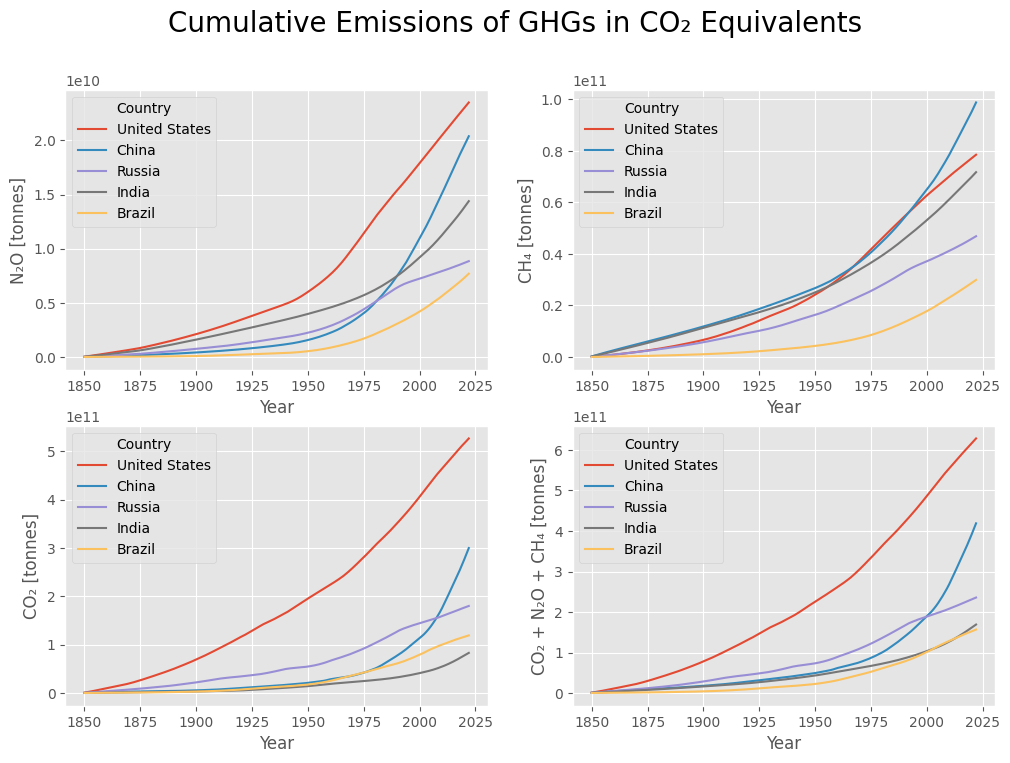

In [33]:
# create the plots

cols = list(df_plot_3)[3:]
y_labels = ['N₂O [tonnes]', 'CH₄ [tonnes]', 'CO₂ [tonnes]',
            'CO₂ + N₂O + CH₄ [tonnes]']

fig, axs = plt.subplots(2, 2)

fig.suptitle("Cumulative Emissions of GHGs in CO₂ Equivalents", fontsize=20)

for ind, col in enumerate(cols):
    i = ind // 2
    j = ind % 2
    sns.lineplot(
        data=df_plot_3,
        x='year',
        y=col,
        hue='Country',
        hue_order=top_5_countries,
        ax=axs[i, j]
    ).set(xlabel="Year", ylabel=y_labels[ind])

Let's create similar plots that trace the annual (instead of cumulative) GHG emissions as a function of time.

In [34]:
# prepare the dataframe

df_plot_4 = df_countries_clean.loc[
    df_countries_clean['entity'].isin(top_5_countries)
    ].rename(columns={'entity': 'Country'})

df_plot_4

,Country,code,year,n2o_in_co2_equivalents_annual,ch4_in_co2_equivalents_annual,co2_annual,total_ghg_in_co2_equivalents_annual
3979,Brazil,BRA,1850,1116825.1,14521671.0,3.268905e+07,4.832754e+07
3980,Brazil,BRA,1851,1134618.5,14743202.0,3.661897e+07,5.249679e+07
3981,Brazil,BRA,1852,1152083.9,14964982.0,3.099257e+07,4.710963e+07
3982,Brazil,BRA,1853,1169018.2,15187010.0,3.377002e+07,5.012605e+07
3983,Brazil,BRA,1854,1185218.8,15409293.0,3.566302e+07,5.225753e+07
...,...,...,...,...,...,...,...
32519,United States,USA,2018,253850160.0,706218500.0,5.317671e+09,6.277740e+09
32520,United States,USA,2019,249157840.0,720631800.0,5.225444e+09,6.195234e+09
32521,United States,USA,2020,246135380.0,682798460.0,4.701300e+09,5.630234e+09
32522,United States,USA,2021,251320220.0,685242560.0,5.025303e+09,5.961866e+09


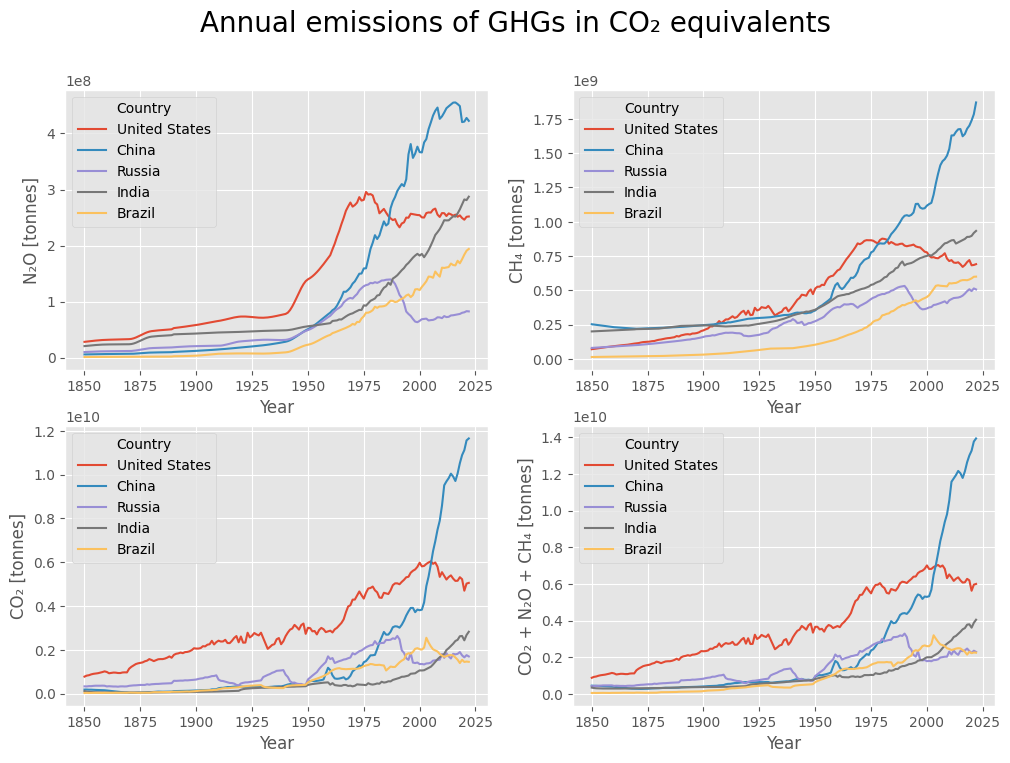

In [35]:
# create the plots

cols = list(df_countries_clean)[3:]
y_labels = ['N₂O [tonnes]', 'CH₄ [tonnes]', 'CO₂ [tonnes]',
            'CO₂ + N₂O + CH₄ [tonnes]']

fig, axs = plt.subplots(2, 2)

fig.suptitle("Annual emissions of GHGs in CO₂ equivalents", fontsize=20)

for ind, col in enumerate(cols):
    i = ind // 2
    j = ind % 2
    sns.lineplot(
        data=df_plot_4,
        x='year',
        y=col,
        hue='Country',
        hue_order=top_5_countries,
        ax=axs[i, j]
    ).set(xlabel="Year", ylabel=y_labels[ind])

Although USA is the all-time highest emitter of GHGs, these graph show that the yearly GHG emissions of China are nowadays almost twice as large as the corresponding emissions of the USA.

## Dashboard to Visualize the Whole Dataset

Let us now create an interactive dashboard that allows us to visualize basically the entire GHG dataset.

In [36]:
external_stylesheets = ['https://codepen.io/chriddyp/pen/bWLwgP.css']

app = Dash(__name__, external_stylesheets=external_stylesheets)


ghg_list = ["N₂O", "CH₄", "CO₂", "N₂O + CH₄ + CO₂"]


app.layout = html.Div([
    html.Div([

        html.Div([
            dcc.Dropdown(  # dropdown for country selection
                options=df_countries_clean['entity'].unique(),
                value=[],
                id='country-selection',
                multi=True  # allows selection of multiple countries
            ),
            dcc.RadioItems(  # switch between per year/cumulated
                ['Per year', 'Cumulated'],
                'Per year',
                id='graph-type',
                labelStyle={'display': 'inline-block', 'marginTop': '5px'}
            )
        ],
            style={'width': '49%', 'display': 'inline-block'}),

        html.Div([
            dcc.Dropdown(  # dropdown for GHG selection
                ghg_list,
                "N₂O + CH₄ + CO₂",
                id='ghg-selection'
            ),
            dcc.RadioItems(  # switch between linear or log y-axis
                ['Linear', 'Log'],
                'Linear',
                id='y-axis-type',
                labelStyle={'display': 'inline-block', 'marginTop': '5px'}
            )
        ],
            style={
                'width': '49%',
                'float': 'right',
                'display': 'inline-block'}
        )
    ],
        style={'padding': '10px 5px'}
    ),

    html.Div([
        dcc.Graph(
            id='emission-year-scatter',
        )
    ], style={'width': '90%', 'display': 'inline-block', 'padding': '0 20'})
])


# callback to update the line plots
@app.callback(
    Output('emission-year-scatter', 'figure'),
    [Input('country-selection', 'value')],
    Input('ghg-selection', 'value'),
    Input('graph-type', 'value'),
    Input('y-axis-type', 'value'))
def update_graph(
    country_selection,
    ghg_selection,
    graph_selection,
    log_scale_y
):
    if not country_selection:  # show an empty figure if no country is selected
        return px.scatter()

    # choose the dataset: annual vs cumulated
    df_internal = df_countries_clean if graph_selection == 'Per year' \
        else df_countries_cumul

    # filter the data as a function of the country selection
    selected_column = list(df_internal)[ghg_list.index(ghg_selection) + 3]
    filtered_data = df_internal.loc[
        df_internal['entity'].isin(country_selection),
        ('entity', 'year', selected_column)
    ]

    # construct the figure
    fig = px.line(
        x=filtered_data['year'],
        y=filtered_data[selected_column],
        color=filtered_data['entity'],
        log_y=(log_scale_y == 'Log'))
    fig.update_traces(hovertemplate=None)
    fig.update_layout(
        margin={'l': 40, 'b': 40, 't': 10, 'r': 0},
        hovermode="x",
        xaxis_title="Year",
        yaxis_title=f"{ghg_selection} emissions [tonnes]",
        legend_title="Countries"
    )

    return fig


if __name__ == '__main__':
    app.run(debug=True, port=8050)

## Map Dashboard

Below is a dashboard which includes a map showing per year/cumulated GHG emissions as a function of time. The year can be selected with the help of an interactive slider.

In [38]:
ghg_list = ["N₂O", "CH₄", "CO₂", "N₂O + CH₄ + CO₂"]
years = df_countries_clean['year'].unique()

app = dash.Dash(__name__)

app.layout = html.Div([
    html.Div([
         dcc.RadioItems(  # select per year/cumulated
                ['Per year', 'Cumulated'],
                'Per year',
                id='graph-type',
                labelStyle={'display': 'inline-block', 'marginTop': '5px'}
            ),
         dcc.Dropdown(  # select GHG
                ghg_list,
                "N₂O + CH₄ + CO₂",
                id='ghg-selection'
            )

    ]),

    dcc.Graph(id='choropleth-map'),

    dcc.Slider(  # year slider
        id='year-slider',
        min=years.min(),
        max=years.max(),
        value=years.min(),
        marks={
            int(yr): str(yr) for yr in range(years.min(), years.max(), 10)
            },  # show the years in steps of 10
        step=None
    )
])


# callback to update the choropleth plot
@app.callback(
    Output('choropleth-map', 'figure'),
    Input('graph-type', 'value'),
    Input('year-slider', 'value'),
    Input('ghg-selection', 'value')
)
def update_choropleth(graph_type, selected_year, ghg_selection):

    if not ghg_selection:  # show empty graph if no GHG is selected
        fig = px.choropleth()
        return fig

    # choose the dataset: per year vs cumulated
    df_internal = df_countries_clean if graph_type == 'Per year' \
        else df_countries_cumul

    # filter the data as a function of the year selection
    selected_column = list(df_internal)[ghg_list.index(ghg_selection) + 3]
    filtered_data = df_internal.loc[
        (df_internal['year'] == selected_year)
        & (df_internal['entity'] != 'World'),
        ('entity', 'code', selected_column)
    ]

    # create the choropleth map
    fig = px.choropleth(
        filtered_data,
        locations='code',  # 3-letter code to identify each country on the map
        color=selected_column,
        hover_name='entity',
        color_continuous_scale=px.colors.sequential.Plasma,
        labels={selected_column: f'{ghg_selection} Emissions'}
    )

    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=500,
        width=1100

    )
    return fig


if __name__ == '__main__':
    app.run(debug=True, port=8052)